### Sensitivity of the fit to the weighting scheme and to the assumed premature-termination fraction

In [36]:
import os, sys, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.getcwd())
os.environ.setdefault("POLII_DATA", "../data")  # run from activity_homeostasis/
import polii_model as pm

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 8,
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

data = pm.load_data()
REF = pm.fit(data, n_starts=40, seed=7)["params"]  # reference settings
print("reference fit:", dict(zip(pm.PARAM_NAMES, np.round(REF, 4))))
print(pd.Series(pm.summarise(REF, data)).round(3).to_string())

# pool colours, matching the main figures
C_NP = "#5bba47"  # N->P, the promoter-proximal (paused) pool
C_PE = "xkcd:medium blue"  # P->E, the elongating pool

reference fit: {'k_pn': np.float64(4.1365), 'Vmax_pe': np.float64(0.337), 'Km_pe': np.float64(0.0314), 'Vmax_np': np.float64(2.7331), 'Km_np': np.float64(0.3186)}
k_pn         4.137
Vmax_pe      0.337
Km_pe        0.031
Vmax_np      2.733
Km_np        0.319
N0           0.401
P0           0.295
E0           0.305
s_np_T0.5    0.272
s_pe_T0.5    0.787
s_np_T0.7    0.402
s_pe_T0.7    0.862
s_np_T1.0    0.557
s_pe_T1.0    0.904
T_low        0.687
T_high         NaN
S_T1         0.090
cost         0.003


In [37]:
def run(label, n_starts=10, **kw):
    """Refit under fitting choices `kw` and summarise the derived quantities."""
    r = pm.fit(data, n_starts=n_starts, seed=11, x0=REF, **kw)
    s = pm.summarise(r["params"], data, **kw)
    s["label"] = label
    # cost of this parameter set re-scored under the REFERENCE weighting, so all
    # rows are comparable on one yardstick
    s["cost_reference_scheme"] = pm.cost(r["params"], data)
    s["n_starts_at_best"] = sum(
        np.abs(np.log10(p) - np.log10(r["params"])).max() < np.log10(1.05)
        for c, p in r["all"]
        if c < 1e5
    )
    print(
        f"  {label:<42s} s_NP={s['s_np_T1.0']:.3f}  s_PE={s['s_pe_T1.0']:.3f}"
        f"  T_low={s['T_low']:.3f}  S={s['S_T1']:.3f}",
        flush=True,
    )
    return s


SHOW = [
    "label",
    "s_np_T1.0",
    "s_pe_T1.0",
    "s_np_T0.7",
    "s_pe_T0.7",
    "T_low",
    "S_T1",
    "P0",
    "Km_np",
    "Km_pe",
    "cost_reference_scheme",
]

## 1. Weighting scheme

The reported fit weights every imaging point equally and gives the genomic
points a threefold higher weight. Block sizes and the resulting total weight
per block:

In [38]:
w = pm.e_weights(data)[data["E_fit"]]
print(
    "imaging points fitted:", len(w), "of", len(data["T_E"]), "- total weight", w.sum()
)
print(
    "FRAP points:           ",
    len(data["T_B"]),
    "- total weight",
    float(len(data["T_B"])),
)
print(
    "dxChIP-seq points fitted:",
    int(data["P_fit"].sum()),
    "of",
    len(data["T_P"]),
    "- total weight",
    3.0 * int(data["P_fit"].sum()),
)
print(
    "Points excluded from fitting are self-normalisation controls (exactly 1 at T = 1 "
    "by construction); they are retained in the data for plotting."
)

imaging points fitted: 67 of 71 - total weight 67.0
FRAP points:            33 - total weight 33.0
dxChIP-seq points fitted: 2 of 3 - total weight 6.0
Points excluded from fitting are self-normalisation controls (exactly 1 at T = 1 by construction); they are retained in the data for plotting.


In [39]:
wE_equal = len(data["T_B"]) / int(
    data["E_fit"].sum()
)  # E block total = FRAP block total
schemes = [
    ("w_P=3, ARMC5 points up-weighted 3x", dict(w_armc5=3.0)),
    ("w_P=1, ARMC5 points up-weighted 3x", dict(w_P=1.0, w_armc5=3.0)),
    (
        "block-balanced (E=FRAP=TSS block totals)",
        dict(w_P=len(data["T_B"]) / int(data["P_fit"].sum()), w_E=wE_equal),
    ),
]
t0 = time.time()
rows = [run(lab, **kw) for lab, kw in schemes]
rows += [run(f"w_P = {v}", w_P=float(v)) for v in [0.5, 1, 2, 3, 5, 10, 20]]
weighting = pd.DataFrame(rows)
weighting.to_csv("table_weighting_sensitivity.csv", index=False)
print(f"{time.time()-t0:.0f} s")
print(weighting[SHOW].round(3).to_string(index=False))

  w_P=3, ARMC5 points up-weighted 3x         s_NP=0.557  s_PE=0.901  T_low=0.690  S=0.093
  w_P=1, ARMC5 points up-weighted 3x         s_NP=0.591  s_PE=0.906  T_low=0.679  S=0.084
  block-balanced (E=FRAP=TSS block totals)   s_NP=0.491  s_PE=0.842  T_low=0.747  S=0.143
  w_P = 0.5                                  s_NP=0.614  s_PE=0.906  T_low=0.675  S=0.081
  w_P = 1                                    s_NP=0.588  s_PE=0.910  T_low=0.675  S=0.081
  w_P = 2                                    s_NP=0.568  s_PE=0.908  T_low=0.681  S=0.086
  w_P = 3                                    s_NP=0.557  s_PE=0.904  T_low=0.687  S=0.090
  w_P = 5                                    s_NP=0.543  s_PE=0.894  T_low=0.699  S=0.100
  w_P = 10                                   s_NP=0.518  s_PE=0.872  T_low=0.722  S=0.119
  w_P = 20                                   s_NP=0.481  s_PE=0.837  T_low=0.749  S=0.146
198 s
                                   label  s_np_T1.0  s_pe_T1.0  s_np_T0.7  s_pe_T0.7  T_low  S

## 2. Assumed premature-termination fraction

$f$ is swept from 40% to 95%. The value $f=80\%$ is the published choice. We also
fit with the constraint removed entirely, to see what the data alone prefer.

In [40]:
F_GRID = [0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9]
t0 = time.time()
pt = pd.DataFrame([run(f"PT = {f:.0%}", n_starts=14, pt_fraction=f) for f in F_GRID])
pt["pt_fraction"] = F_GRID
pt.to_csv("table_pt_sensitivity.csv", index=False)
print(f"{time.time()-t0:.0f} s")
print(pt[["pt_fraction"] + SHOW[1:]].round(3).to_string(index=False))

  PT = 40%                                   s_NP=0.777  s_PE=0.900  T_low=0.688  S=0.086
  PT = 50%                                   s_NP=0.729  s_PE=0.904  T_low=0.684  S=0.085
  PT = 60%                                   s_NP=0.675  s_PE=0.906  T_low=0.683  S=0.085
  PT = 70%                                   s_NP=0.617  s_PE=0.906  T_low=0.683  S=0.087
  PT = 75%                                   s_NP=0.587  s_PE=0.905  T_low=0.685  S=0.088
  PT = 80%                                   s_NP=0.557  s_PE=0.904  T_low=0.687  S=0.090
  PT = 85%                                   s_NP=0.528  s_PE=0.901  T_low=0.690  S=0.093
  PT = 90%                                   s_NP=0.499  s_PE=0.898  T_low=0.694  S=0.097
219 s
 pt_fraction  s_np_T1.0  s_pe_T1.0  s_np_T0.7  s_pe_T0.7  T_low  S_T1    P0  Km_np  Km_pe  cost_reference_scheme
        0.40      0.777      0.900      0.653      0.858  0.688 0.086 0.324  0.112  0.036                  0.855
        0.50      0.729      0.904      0.591   

Enforcing a high $f$ requires a large $k_{PN}$ ($J_{P\to N}=k_{PN}P$ must be
$f/(1-f)$ times the P→E flux), so above $f\approx0.9$ the fit runs into the
published parameter bound $k_{PN}\le10$. We therefore check which parameters
sit at a bound, and repeat the sweep with the rate bounds widened 100-fold.

In [41]:
at_bound = pd.DataFrame(
    {
        "pt_fraction": pt.pt_fraction,
        **{
            n: [
                f"{v:.3g}{'  <-BOUND' if (abs(v - lo) < 1e-6 or abs(v - hi) < 1e-6 * hi) else ''}"
                for v in pt[n]
            ]
            for n, (lo, hi) in zip(pm.PARAM_NAMES, pm.BOUNDS)
        },
    }
)
print(at_bound.to_string(index=False))

BOUNDS_PUBLISHED = list(pm.BOUNDS)
pm.BOUNDS = [(1e-4, 1000), (1e-4, 100), (1e-6, 10), (1e-4, 1000), (1e-6, 10)]
try:
    wide = pd.DataFrame(
        [
            run(f"PT = {f:.0%} (wide bounds)", n_starts=14, pt_fraction=f)
            for f in [0.4, 0.6, 0.8, 0.9, 0.95, 0.98]
        ]
    )
finally:
    pm.BOUNDS = BOUNDS_PUBLISHED
wide.to_csv("table_pt_sensitivity_wide_bounds.csv", index=False)
print(wide[SHOW].round(3).to_string(index=False))

 pt_fraction  k_pn Vmax_pe  Km_pe Vmax_np Km_np
        0.40 0.589   0.317 0.0358   0.612 0.112
        0.50 0.918   0.321 0.0338   0.798 0.146
        0.60  1.44   0.327 0.0321     1.1  0.19
        0.70  2.33   0.332 0.0312    1.63 0.247
        0.75  3.06   0.335 0.0311    2.07 0.281
        0.80  4.14   0.337 0.0314    2.73 0.319
        0.85  5.92   0.339  0.032    3.86  0.36
        0.90  9.46    0.34  0.033    6.12 0.406
  PT = 40% (wide bounds)                     s_NP=0.777  s_PE=0.900  T_low=0.688  S=0.086
  PT = 60% (wide bounds)                     s_NP=0.675  s_PE=0.906  T_low=0.683  S=0.085
  PT = 80% (wide bounds)                     s_NP=0.557  s_PE=0.904  T_low=0.687  S=0.090
  PT = 90% (wide bounds)                     s_NP=0.499  s_PE=0.898  T_low=0.694  S=0.097
  PT = 95% (wide bounds)                     s_NP=0.471  s_PE=0.894  T_low=0.699  S=0.101
  PT = 98% (wide bounds)                     s_NP=0.460  s_PE=0.886  T_low=0.706  S=0.106
                 label  s_np

### How much does the data cost actually change with $f$?

For each $f$ we record the **data-only** weighted SSE (penalty excluded,
reference weights), and express it as
$\Delta\chi^2=(\mathrm{SSE}-\mathrm{SSE}_{\min})/\hat\sigma^2$ with
$\hat\sigma^2=\mathrm{SSE}(f{=}0.8)/(n-p)$, $n=102$ fitted measurements and
$p=5$ — the same scale as the parameter profiles in
`pol_pools_identifiability.ipynb`, so the two notebooks put $\Delta\chi^2$ on one
yardstick. This is a likelihood profile in the imposed constraint itself.

In [42]:
i0 = pm.cost(REF, data, full=True)
# Residual-variance scale, identical to pol_pools_identifiability.ipynb: the
# weighted residual sum of squares over (number of MEASUREMENTS - number of
# fitted parameters).  The weights are relative precisions, so they scale the
# residuals rather than counting as replicates: the denominator is n_obs - p,
# not the sum of the weights (n_eff - p).
SSE0, NOBS = i0["sse"], i0["n_obs"]
SIG2 = SSE0 / (NOBS - 5)
print(
    f"SSE_min = {SSE0:.5g}, n = {NOBS:d} measurements, {NOBS - 5:d} residual df, "
    f"sigma^2_hat = {SIG2:.5g}"
)
rows = []
for direction in (np.arange(0.80, 0.991, 0.025), np.arange(0.80, 0.049, -0.025)):
    x = REF.copy()  # walk outwards from f = 0.8 both ways
    for f in np.round(direction, 3):
        r = pm.fit(data, n_starts=6, seed=13, x0=x, pt_fraction=f)
        x = r["params"]
        i2 = pm.cost(x, data, full=True, pt_fraction=f)
        s_np, s_pe = pm.saturation(1.0, x)
        rows.append(
            dict(
                pt_fraction=f,
                sse=i2["sse"],
                dchi2=(i2["sse"] - SSE0) / SIG2,
                s_np=s_np,
                s_pe=s_pe,
                T_low=pm.buffering_range(x)[0],
                S_T1=pm.log_sensitivity(x),
                k_pn=x[0],
                at_kpn_bound=abs(x[0] - pm.BOUNDS[0][1]) < 1e-3,
            )
        )
pt_prof = pd.DataFrame(rows).sort_values("pt_fraction")
pt_prof.to_csv("table_pt_profile.csv", index=False)
print(pt_prof.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7 / 2.54, 4.5 / 2.54))
ax.plot(pt_prof.pt_fraction, pt_prof.dchi2, "o-", ms=3, color="#333333")
ax.axhline(3.841, color="#d62728", lw=0.8, ls="--")
ax.axvline(0.8, color="#419c46", lw=0.8)
ax.set_xlabel("imposed premature-termination fraction $f$")
ax.set_ylabel(r"$\Delta\chi^2$ (data only)")
ax.set_ylim(-10, 60)
fig.tight_layout()
fig.savefig("fig_pt_profile.pdf")

KeyError: 'n_obs'

In [ ]:
free = pm.fit(data, n_starts=60, seed=3, x0=REF, constraint_weight=0.0)
s_free = pm.summarise(free["params"], data, constraint_weight=0.0)
s_free["pt_achieved"] = pm.cost(free["params"], data, full=True, constraint_weight=0.0)[
    "pt_achieved"
]
print("Constraint removed entirely:")
print(pd.Series(s_free).round(3).to_string())

Constraint removed entirely:
k_pn           0.010
Vmax_pe        0.343
Km_pe          0.035
Vmax_np        0.330
Km_np          0.028
N0             0.406
P0             0.288
E0             0.306
s_np_T0.5      0.806
s_pe_T0.5      0.773
s_np_T0.7      0.885
s_pe_T0.7      0.847
s_np_T1.0      0.935
s_pe_T1.0      0.892
T_low          0.703
T_high           NaN
S_T1           0.103
cost           0.003
pt_achieved    0.009


## 3. Joint grid

In [ ]:
t0, rows = time.time(), []
for f in [0.5, 0.6, 0.7, 0.8, 0.9]:
    x = REF.copy()
    for v in [1, 2, 3, 5, 10]:
        # warm start from the neighbouring grid cell as well as random starts,
        # so a single unlucky local optimum cannot create a false kink
        r = pm.fit(data, n_starts=12, seed=5, x0=x, pt_fraction=f, w_P=float(v))
        x = r["params"]
        s = pm.summarise(x, data, pt_fraction=f, w_P=float(v))
        rows.append({**s, "pt_fraction": f, "w_P": v})
    print("PT", f, flush=True)
grid = pd.DataFrame(rows)
grid.to_csv("table_joint_grid.csv", index=False)
print(f"{time.time()-t0:.0f} s")

PT 0.5
PT 0.6
PT 0.7
PT 0.8
PT 0.9
301 s


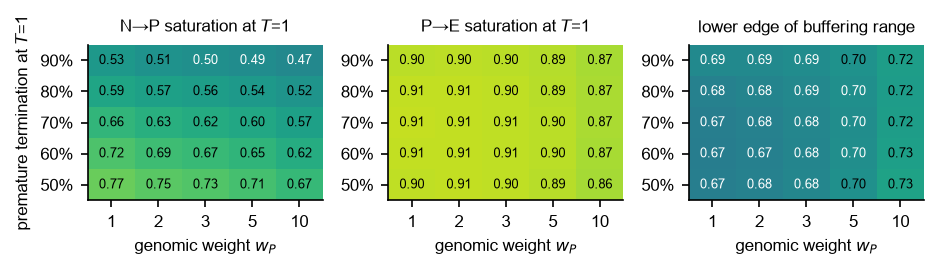

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16 / 2.54, 4.6 / 2.54))
for ax, (c, lab, vlim) in zip(
    axes,
    [
        ("s_np_T1.0", "N→P saturation at $T$=1", (0, 1)),
        ("s_pe_T1.0", "P→E saturation at $T$=1", (0, 1)),
        ("T_low", "lower edge of buffering range", (0.5, 0.9)),
    ],
):
    m = grid.pivot(index="pt_fraction", columns="w_P", values=c)
    im = ax.imshow(
        m.values,
        origin="lower",
        cmap="viridis",
        aspect="auto",
        vmin=vlim[0],
        vmax=vlim[1],
    )
    ax.set_xticks(range(len(m.columns)), m.columns)
    ax.set_yticks(range(len(m.index)), [f"{i:.0%}" for i in m.index])
    ax.set_xlabel("genomic weight $w_P$")
    ax.set_title(lab, fontsize=8)
    for (i, j), v in np.ndenumerate(m.values):
        ax.text(
            j,
            i,
            f"{v:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color="w" if v < (vlim[0] + vlim[1]) / 2 else "k",
        )
axes[0].set_ylabel("premature termination at $T$=1")
fig.tight_layout()
fig.savefig("fig_joint_grid.pdf")

## 4. Summary figure

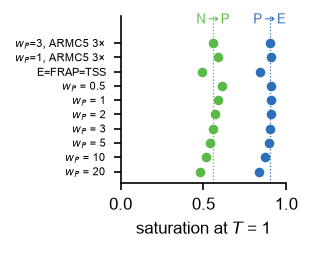

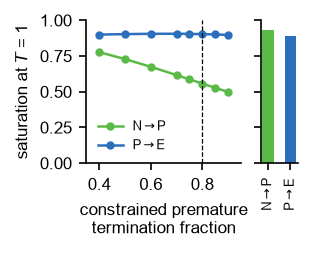

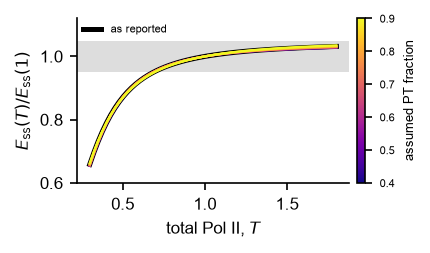

In [ ]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

T = np.linspace(0.3, 1.8, 60)


def rel_E(p):
    return np.array([pm.steady_state(t, p)[2] for t in T]) / pm.steady_state(1, p)[2]


# --- Figure S9M: weighting -----------------------------------------------------
LABEL_DISPLAY = {
    "w_P=3, ARMC5 points up-weighted 3x": "$w_P$=3, ARMC5 3×",
    "w_P=1, ARMC5 points up-weighted 3x": "$w_P$=1, ARMC5 3×",
    "block-balanced (E=FRAP=TSS block totals)": "E=FRAP=TSS",
    "w_P = 0.5": "$w_P$ = 0.5",
    "w_P = 1": "$w_P$ = 1",
    "w_P = 2": "$w_P$ = 2",
    "w_P = 3": "$w_P$ = 3",
    "w_P = 5": "$w_P$ = 5",
    "w_P = 10": "$w_P$ = 10",
    "w_P = 20": "$w_P$ = 20",
}

fig, ax = plt.subplots(figsize=(5.0 / 2.54, 4.0 / 2.54), layout="constrained")
y = np.arange(len(weighting))[::-1]
ax.scatter(weighting["s_np_T1.0"], y, s=13, color=C_NP)
ax.scatter(weighting["s_pe_T1.0"], y, s=13, color=C_PE)
tick_labels = [
    LABEL_DISPLAY.get(lab, lab.replace("w_P", r"$w_P$")) for lab in weighting["label"]
]
ax.set_yticks(y, tick_labels, fontsize=5.5)
ax.set_ylim(-0.8, len(weighting) + 0.9)
ax.set_xlim(0, 1)
ax.set_xlabel("saturation at $T$ = 1")
for c, col, lab in (
    ("s_np_T1.0", C_NP, r"N$\to$P"),
    ("s_pe_T1.0", C_PE, r"P$\to$E"),
):
    ax.axvline(weighting[c].iloc[0], color=col, lw=0.6, ls=":")
    ax.text(
        weighting[c].iloc[0],
        len(weighting) + 0.2,
        lab,
        color=col,
        fontsize=6,
        ha="center",
        va="bottom",
    )
fig.savefig("plots/fig_weighting_sensitivity.pdf")

# --- Figure S9N: saturation vs PT fraction + unconstrained bar -----------------
fig = plt.figure(figsize=(5 / 2.54, 4 / 2.54), layout="constrained")
gs = fig.add_gridspec(1, 2, width_ratios=[2.5, 0.6])
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

# constrained fits: saturation vs PT fraction (40–90% range)
ax0.plot(
    pt["pt_fraction"], pt["s_np_T1.0"], "o-", ms=3, lw=1.2, color=C_NP, label=r"N$\to$P"
)
ax0.plot(
    pt["pt_fraction"], pt["s_pe_T1.0"], "o-", ms=3, lw=1.2, color=C_PE, label=r"P$\to$E"
)
ax0.axvline(0.8, color="k", lw=0.6, ls="--")
ax0.set_xlim(0.35, 0.95)
ax0.set_ylim(0, 1)
ax0.set_xlabel("constrained premature\ntermination fraction")
ax0.set_ylabel("saturation at $T$ = 1")
ax0.legend(frameon=False, fontsize=6, loc="lower left")

# unconstrained fit saturation as a bar chart
ax1.bar([0], [s_free["s_np_T1.0"]], color=C_NP, width=0.5)
ax1.bar([1], [s_free["s_pe_T1.0"]], color=C_PE, width=0.5)
ax1.set_xticks([0, 1], [r"N$\to$P", r"P$\to$E"], fontsize=6)
ax1.tick_params(axis="x", rotation=90)
ax1.set_ylim(0, 1)
ax1.tick_params(labelleft=False)

fig.savefig("plots/fig_pt_sensitivity.pdf")

# --- Figure S9N (cont.): E_ss curves ------------------------------------------
norm_f = Normalize(pt["pt_fraction"].min(), pt["pt_fraction"].max())
fig, ax2 = plt.subplots(figsize=(7 / 2.54, 4 / 2.54), layout="constrained")
ax2.axhspan(0.95, 1.05, color="#dddddd", lw=0)
ax2.plot(T, rel_E(REF), lw=2.4, color="k", zorder=1, label="as reported")
for f, p in zip(pt["pt_fraction"], pt[pm.PARAM_NAMES].values):
    ax2.plot(T, rel_E(p), lw=1.1, color=plt.cm.plasma(norm_f(f)), zorder=2)
ax2.set_ylim(0.6, 1.12)
ax2.set_xlabel("total Pol II, $T$")
ax2.set_ylabel("$E_{\\rm ss}(T)/E_{\\rm ss}(1)$")
cb = fig.colorbar(
    ScalarMappable(norm=norm_f, cmap="plasma"), ax=ax2, pad=0.03, fraction=0.055
)
cb.set_label("assumed PT fraction", fontsize=6)
cb.ax.tick_params(labelsize=5.5)
ax2.legend(
    frameon=False, fontsize=5.5, loc="upper left", handlelength=1.6, borderaxespad=0.1
)
fig.savefig("plots/fig_pt_ess.pdf")

## 5. Ranges across every fit performed here

In [ ]:
allfits = pd.concat(
    [
        weighting.assign(analysis="weighting"),
        pt.assign(analysis="PT fraction"),
        grid.assign(analysis="joint grid"),
    ],
    ignore_index=True,
)
rng_tab = allfits.groupby("analysis")[["s_np_T1.0", "s_pe_T1.0", "T_low", "S_T1"]].agg(
    ["min", "max"]
)
print(rng_tab.round(3).to_string())
print(
    "\nacross ALL refits: s_NP %.2f-%.2f, s_PE %.2f-%.2f, "
    "s_PE > s_NP in %d/%d fits"
    % (
        allfits["s_np_T1.0"].min(),
        allfits["s_np_T1.0"].max(),
        allfits["s_pe_T1.0"].min(),
        allfits["s_pe_T1.0"].max(),
        (allfits["s_pe_T1.0"] > allfits["s_np_T1.0"]).sum(),
        len(allfits),
    )
)
allfits.to_csv("table_all_sensitivity_fits.csv", index=False)

            s_np_T1.0        s_pe_T1.0         T_low          S_T1       
                  min    max       min    max    min    max    min    max
analysis                                                                 
PT fraction     0.499  0.777     0.898  0.906  0.683  0.694  0.085  0.097
joint grid      0.466  0.773     0.864  0.910  0.670  0.730  0.074  0.124
weighting       0.481  0.614     0.837  0.910  0.675  0.749  0.081  0.146

across ALL refits: s_NP 0.47-0.78, s_PE 0.84-0.91, s_PE > s_NP in 43/43 fits
